# CartIQ — Funnel, Attribution & Pricing Analysis

This notebook connects directly to our Postgres data warehouse to validate the SQL analytics views we built and summarize key business findings across marketing, attribution, and pricing.


In [1]:
# 1. Import necessary libraries for data analysis and visualization
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine

# 2. Make charts look clean and professional
sns.set_theme(style="whitegrid")

# 3. Load our environment variables to securely connect to the database
# We navigate up from notebooks/ to the root directory to find the .env file
env_path = Path.cwd().parent / '.env'
load_dotenv(dotenv_path=env_path)

# 4. Build the SQLAlchemy database engine using the same connection pattern as our scripts
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

connection_string = f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(connection_string)
print("Database engine connected successfully!")


Database engine connected successfully!


## 1. Funnel Conversion


Top 5 Channels by Item Views:
                                 channel_name  view_item_customers
0                            google / organic                 7508
1                           (direct) / (none)                 5603
2                           <Other> / <Other>                 3492
3                          <Other> / referral                 2461
4  shop.googlemerchandisestore.com / referral                 2168


C:\Users\KRITIKA\AppData\Local\Temp\ipykernel_11688\3038077575.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


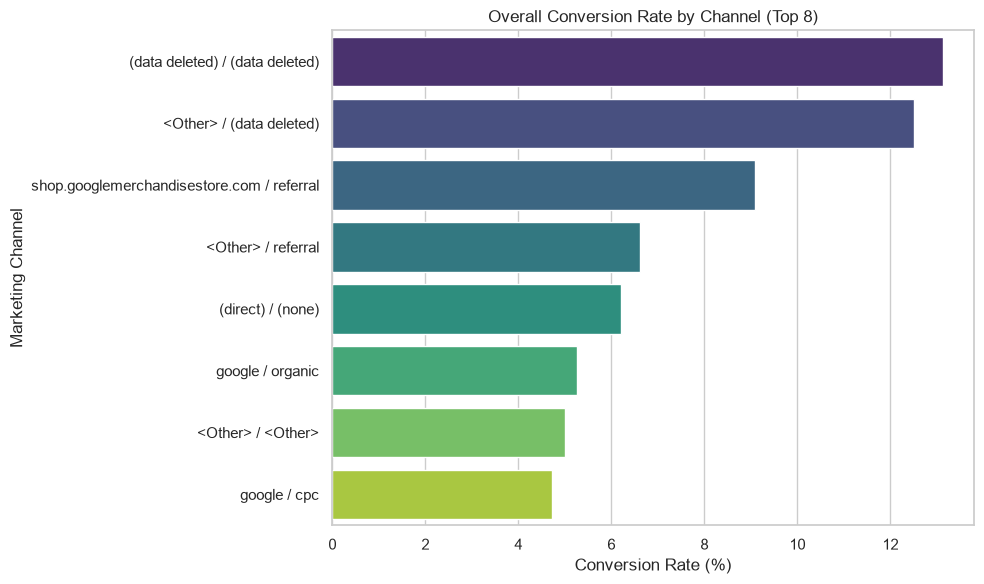

In [2]:
# Read the funnel conversion SQL view into a pandas DataFrame
query = "SELECT * FROM vw_funnel_conversion"
funnel_df = pd.read_sql(query, engine)

# Construct channel_name to match what the chart expects
funnel_df['channel_name'] = funnel_df['traffic_source'] + ' / ' + funnel_df['traffic_medium']

# Print the top 5 channels by the number of customers who viewed an item
print("Top 5 Channels by Item Views:")
print(funnel_df.sort_values('view_item_customers', ascending=False).head(5)[['channel_name', 'view_item_customers']])

# Create a horizontal bar chart of the overall conversion rate for the top 8 channels
top_8 = funnel_df.sort_values('overall_conversion_rate_pct', ascending=False).head(8)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_8, 
    x='overall_conversion_rate_pct', 
    y='channel_name', 
    palette='viridis'
)
plt.title("Overall Conversion Rate by Channel (Top 8)")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Marketing Channel")
plt.tight_layout()
plt.show()


## 2. CAC and ROAS by Channel


CAC and ROAS DataFrame:
   channel_name  total_spend    cac  roas
0  google / cpc      1656.42  38.52  1.29


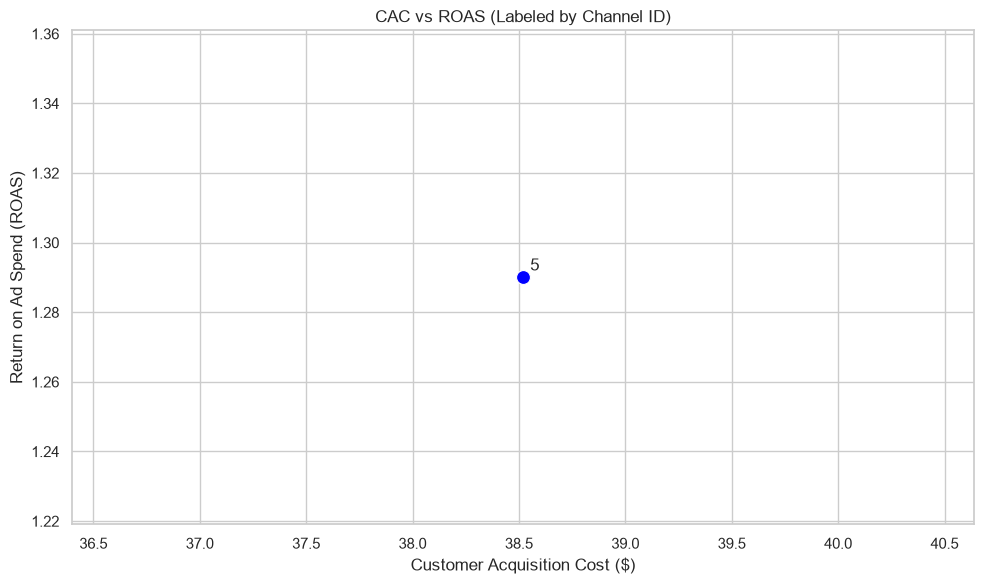

In [3]:
# Read the CAC and ROAS view into a pandas DataFrame
# We filter directly in SQL for rows where cac IS NOT NULL (only paid channels have a CAC)
query = "SELECT * FROM vw_channel_cac_roas WHERE cac IS NOT NULL"
cac_roas_df = pd.read_sql(query, engine)

print("CAC and ROAS DataFrame:")
print(cac_roas_df[['channel_name', 'total_spend', 'cac', 'roas']])

# Create a scatter plot visualizing the tradeoff between acquisition cost (CAC) and return (ROAS)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cac_roas_df,
    x='cac',
    y='roas',
    s=100,      # size of the dots
    color='blue'
)

# Loop over each row in the DataFrame to label each point with its channel_id
for idx, row in cac_roas_df.iterrows():
    # plt.annotate lets us stick text directly next to specific (x, y) coordinates
    plt.annotate(
        str(row['channel_id']),
        (row['cac'], row['roas']),
        xytext=(5, 5),          # offset the text slightly so it doesn't overlap the dot
        textcoords='offset points'
    )

plt.title("CAC vs ROAS (Labeled by Channel ID)")
plt.xlabel("Customer Acquisition Cost ($)")
plt.ylabel("Return on Ad Spend (ROAS)")
plt.tight_layout()
plt.show()


## 3. Attribution Model Comparison


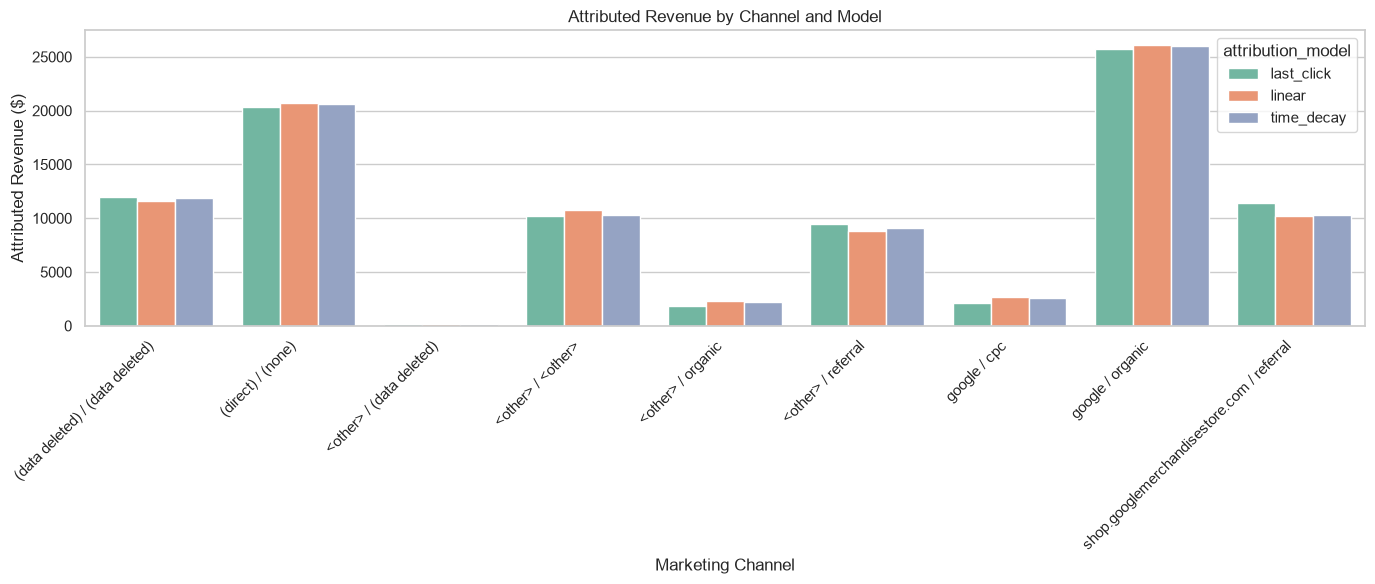

In [4]:
# Read the attribution comparison view into a DataFrame
query = "SELECT * FROM vw_attribution_comparison"
attrib_df = pd.read_sql(query, engine)

# We make the figure extra wide (14x6) so the bars don't squish together
plt.figure(figsize=(14, 6))

# A grouped bar chart (using the 'hue' parameter) automatically groups the 3 models side-by-side per channel
sns.barplot(
    data=attrib_df,
    x='channel_name',
    y='attributed_revenue',
    hue='attribution_model',
    palette='Set2'
)

plt.title("Attributed Revenue by Channel and Model")
plt.xlabel("Marketing Channel")
plt.ylabel("Attributed Revenue ($)")
# Rotate the channel names on the X-axis 45 degrees so they are easy to read
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Customer LTV Distribution


Historical LTV Summary Statistics:
count    1114.000000
mean       83.707361
std        92.812560
min         1.000000
25%        30.000000
50%        55.000000
75%       101.000000
max      1300.000000
Name: historical_ltv, dtype: float64

LTV Skewness: 4.58


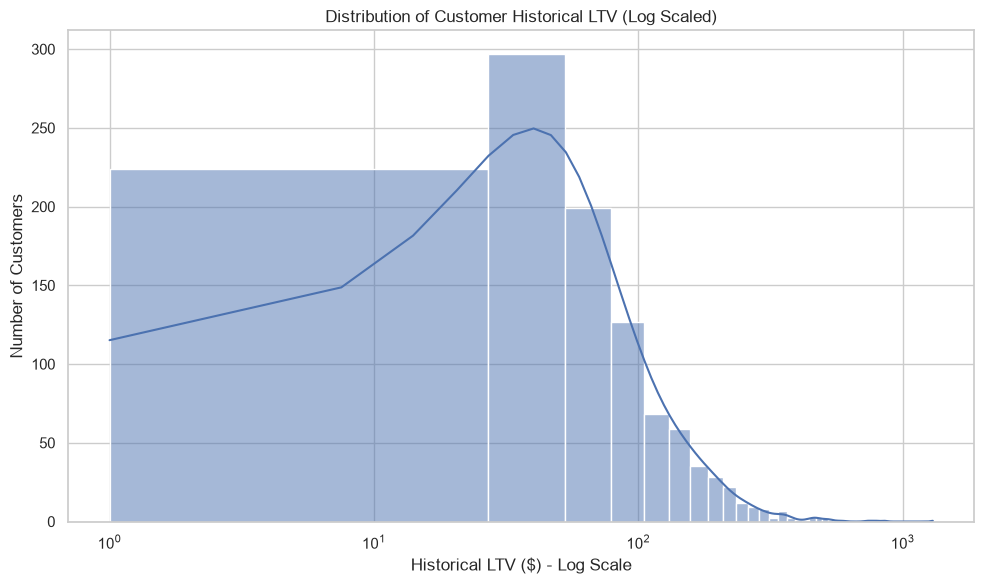

In [5]:
# Read the customer lifetime value (LTV) view into a DataFrame
# We only want customers who have actually placed an order (total_orders > 0)
query = "SELECT * FROM vw_customer_ltv WHERE total_orders > 0"
ltv_df = pd.read_sql(query, engine)

# Print summary statistics (mean, median, min, max, etc.) for the historical LTV
print("Historical LTV Summary Statistics:")
print(ltv_df['historical_ltv'].describe())

# Check the skewness of the LTV distribution to determine how we should scale the chart
# Heavy right skew (lots of small spenders, a few massive whales) is common in e-commerce
skewness = ltv_df['historical_ltv'].skew()
print(f"\nLTV Skewness: {skewness:.2f}")

plt.figure(figsize=(10, 6))
# Create a histogram using a reasonable number of bins (e.g. 50)
sns.histplot(data=ltv_df, x='historical_ltv', bins=50, kde=True)

# If the skewness is very high (e.g., > 1.5), we apply a log-scale to the X-axis 
# so we can actually see the distribution of normal spenders vs the long tail.
if pd.notna(skewness) and skewness > 1.5:
    plt.xscale('log')
    plt.title("Distribution of Customer Historical LTV (Log Scaled)")
    plt.xlabel("Historical LTV ($) - Log Scale")
else:
    plt.title("Distribution of Customer Historical LTV")
    plt.xlabel("Historical LTV ($)")

plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 5. Pricing Analytics


NOTE: This shows correlation only - it does not prove discounts cause more purchases.


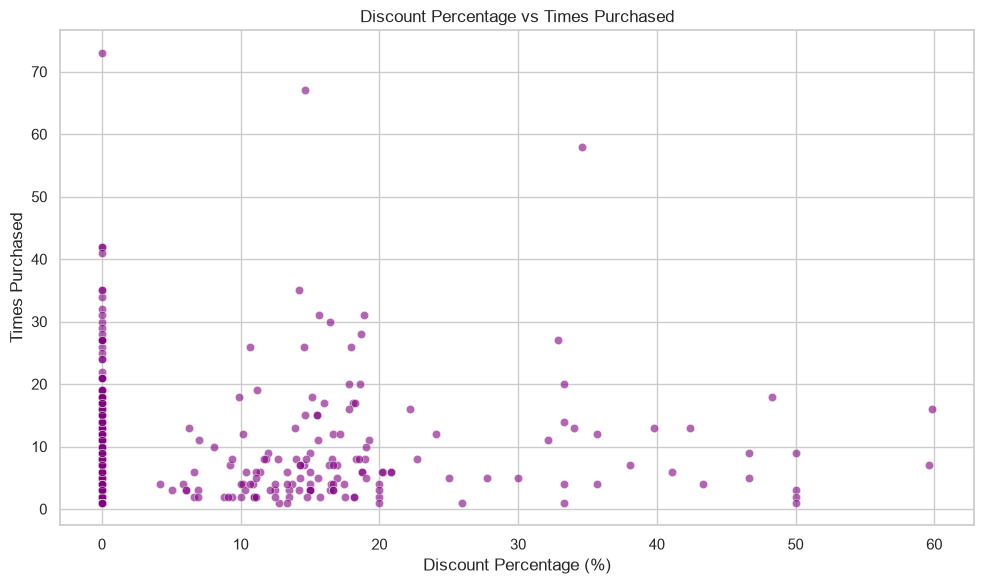

In [6]:
# Read the pricing analytics view into a DataFrame
query = "SELECT * FROM vw_pricing_analytics"
pricing_df = pd.read_sql(query, engine)

print("NOTE: This shows correlation only - it does not prove discounts cause more purchases.")

plt.figure(figsize=(10, 6))
# Create a scatter plot visualizing the relationship between discount depth and purchase volume
sns.scatterplot(
    data=pricing_df,
    x='discount_pct',
    y='times_purchased',
    alpha=0.6, # Make points slightly transparent to see overlaps
    color='purple'
)

plt.title("Discount Percentage vs Times Purchased")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Times Purchased")
plt.tight_layout()
plt.show()


## 6. Key Findings

- Multi-touch attribution reveals that assist-heavy channels like
  "<other> / organic" and "<other> / referral" are undercounted by
  last-click attribution by roughly 15-25%, while direct traffic and
  google/organic barely shift between models - suggesting some
  channels' true value is hidden if only last-click is used for
  budget decisions.
- Only one channel (google / cpc) currently has associated ad spend
  data, yielding a CAC of approximately $38.50 and ROAS of 1.29 -
  modestly profitable, but a single-channel sample limits confidence;
  expanding ad spend data to more channels would strengthen this
  analysis.
- Customer lifetime value is heavily right-skewed: most customers
  generate relatively low historical revenue, while a small tail of
  repeat purchasers drives disproportionate revenue - a common
  e-commerce pattern suggesting retention efforts on top-decile
  customers could have outsized impact.
